In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sqlite3
from wordcloud import WordCloud

In [3]:
df = pd.read_csv('../Data/chocolate_bar_ratings_2022_cleaned.csv')

How many chocolate bars received each rating?       

I chose a histogram (or boxplot) because it helps you visualize the spread, skew, and shape of the data.    

I noticed that the data is skewed toward the higher end of the rating scale. More bars are rated between 3.0 and 3.5 than any other value. In a normal distribution, most of the data would be clustered around the mean of 2.5 on a 1-4 rating scale. In this case, the mean is 3.1.     

I chose 20 bins. I thought 15 looked better visually but it might have exaggerated the shape and skew of the data.      

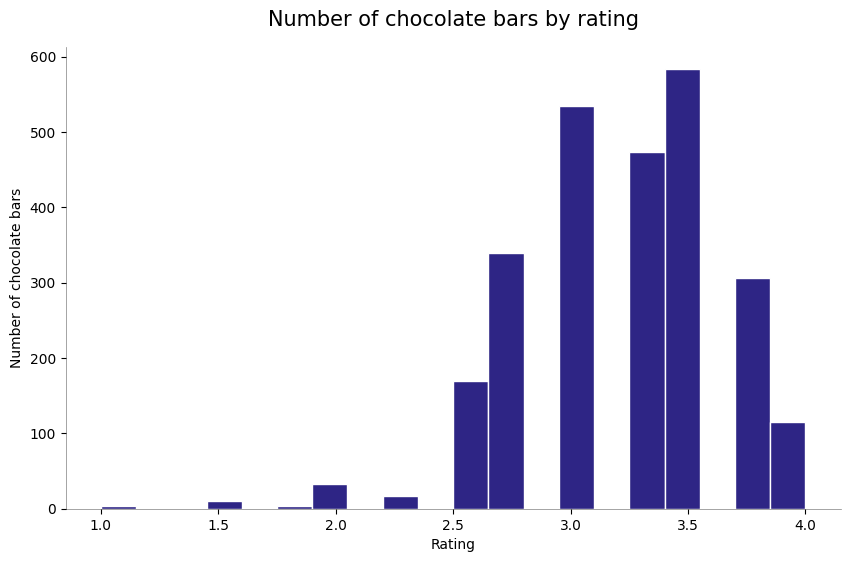

In [14]:
plt.figure(figsize=(10, 6))
plt.hist(
    df['Rating'],
    bins=20, 
    color='#2E2585',
    edgecolor='white'
)

plt.xlabel('Rating')
plt.ylabel('Number of chocolate bars')
plt.title('Number of chocolate bars by rating', fontsize=15, pad=15)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_alpha(0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

Here is a bar chart that shows the top 10 countries for bean production. I chose this chart because I thought including all 62 countries was too visually distracting and isn't meaningful. A bar chart is appropriate here for comparing quantities across variables.  I raised the y-axis limit to 350 to reduce the look of exaggerated data. The previous limit was 250, the height of the tallest bar. 

In [15]:
highest_bean_origin = df['Bean Origin'].value_counts().head(10)
highest_bean_origin

Bean Origin
Venezuela             254
Peru                  248
Dominican Republic    234
Ecuador               223
Madagascar            184
Blend                 156
Nicaragua             103
Tanzania               81
Bolivia                81
Brazil                 81
Name: count, dtype: int64

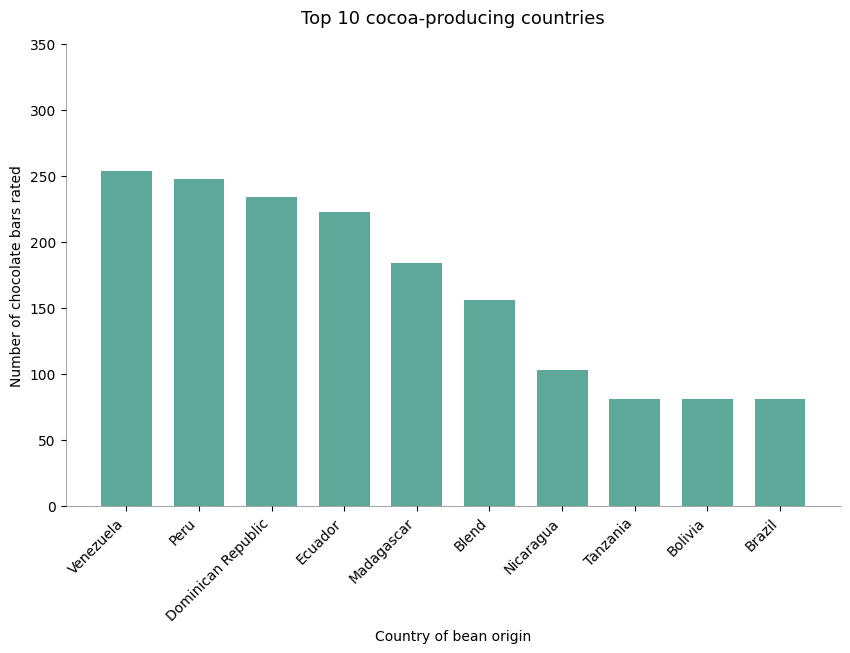

In [16]:
plt.figure(figsize=(10, 6))
plt.bar(highest_bean_origin.index, highest_bean_origin.values,
        color = "#5DA899",
        width = .7
        )

plt.xlabel('Country of bean origin')
plt.ylabel('Number of chocolate bars rated')
plt.ylim(top = 350)
plt.title('Top 10 cocoa-producing countries', fontsize=13, pad=15)
plt.xticks(rotation=45, ha='right')


ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_alpha(0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

    


This next bar chart highlights the top countries in terms of chocolate bar manufacturing. I thought that focusing on the top 10 would be meaningful to audiences. What stands out is that USA is the single largest producer of the chocolate bars *in this review*. It is also interesting that Ecuador is in the top 10 of both the cocoa-producing and chocolate-manufacturing countries. A bar chart is appropriate for this data because it gives quantities (number of bars rated) of categorical variables (top 10 countries). I tried to avoid misleading data by using a y-axis that starts at zero and a neutral color. I raised the y-axis limit to 1400 to reduce the appearance of exaggerated data (it previously went to just 1200, slightly beyond the tallest bar).

In [17]:
highest_company_location = df['Company Location'].value_counts().head(10)
highest_company_location

Company Location
U.S.A.         1168
France          179
Canada          178
U.K.            134
Italy            79
Belgium          72
Ecuador          58
Australia        53
Switzerland      44
Germany          43
Name: count, dtype: int64

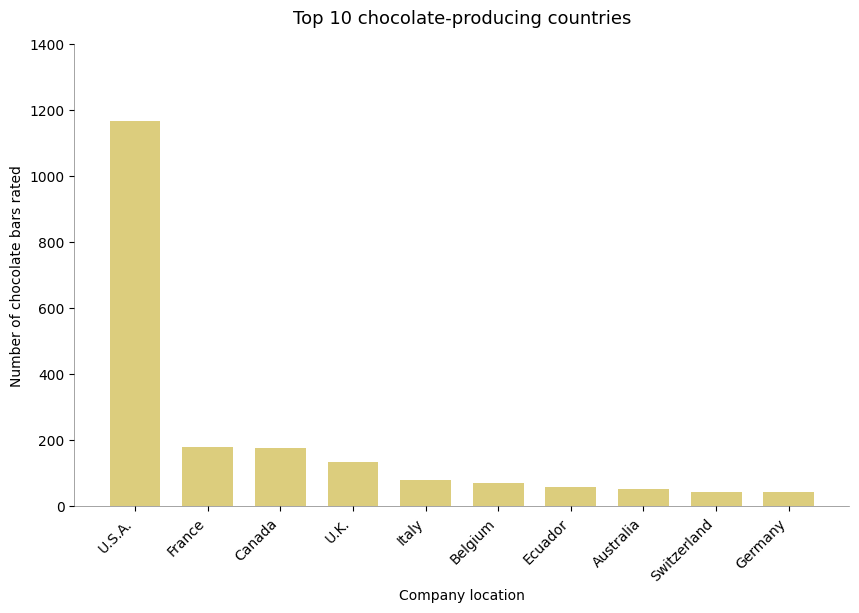

In [18]:
plt.figure(figsize=(10, 6))
plt.bar(highest_company_location.index, highest_company_location.values,
        color = '#DCCD7D',
        width = .7
        )

plt.xlabel('Company location')
plt.ylabel('Number of chocolate bars rated')
plt.ylim(top=1400)
plt.title('Top 10 chocolate-producing countries', fontsize=13, pad=15)
plt.xticks(rotation=45, ha='right')


ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_alpha(0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

Next, I will explore a possible trend in cocoa percentage according to bean origin.  

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2588 entries, 0 to 2587
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   REF               2588 non-null   int64  
 1   Company           2588 non-null   str    
 2   Company Location  2588 non-null   str    
 3   Review Date       2588 non-null   int64  
 4   Bean Origin       2588 non-null   str    
 5   Bar Name          2588 non-null   str    
 6   Cocoa %           2588 non-null   float64
 7   Ingredients       2588 non-null   str    
 8   Characteristics   2588 non-null   str    
 9   Rating            2588 non-null   float64
dtypes: float64(2), int64(2), str(6)
memory usage: 202.3 KB


Group by bean origin and calculate the average cocoa percentage using .mean(). I also want to order these values from least to most cocoa percentage using .sort_values()

In [19]:
avg_cocoa_percent = df.groupby('Bean Origin')['Cocoa %'].mean().sort_values()
avg_cocoa_percent 

Bean Origin
Martinique    42.000000
Bali          65.000000
Tobago        65.000000
Sulawesi      66.000000
DR Congo      68.000000
                ...    
Ecuador       73.253363
Cuba          74.153846
Gabon         75.000000
Principe      77.000000
Samoa         82.333333
Name: Cocoa %, Length: 63, dtype: float64

This bar chart comparing cocoa percentage and bean origin country doesn't really tell me much. Most of the cocoa percentages are in the 70% range.    

 I think the percentage of cocoa in the chocolate would depend on the quantities of other ingredients added to it (the more sweetener, lecithin, vanilla, etc, the lower the percentage of cocoa (beans and cocoa butter combined)), not on where the bean comes from. A better chart might be seeing how the cocoa percentage influences the rating. But then again, that might also have something to do with the taster's preferences.    

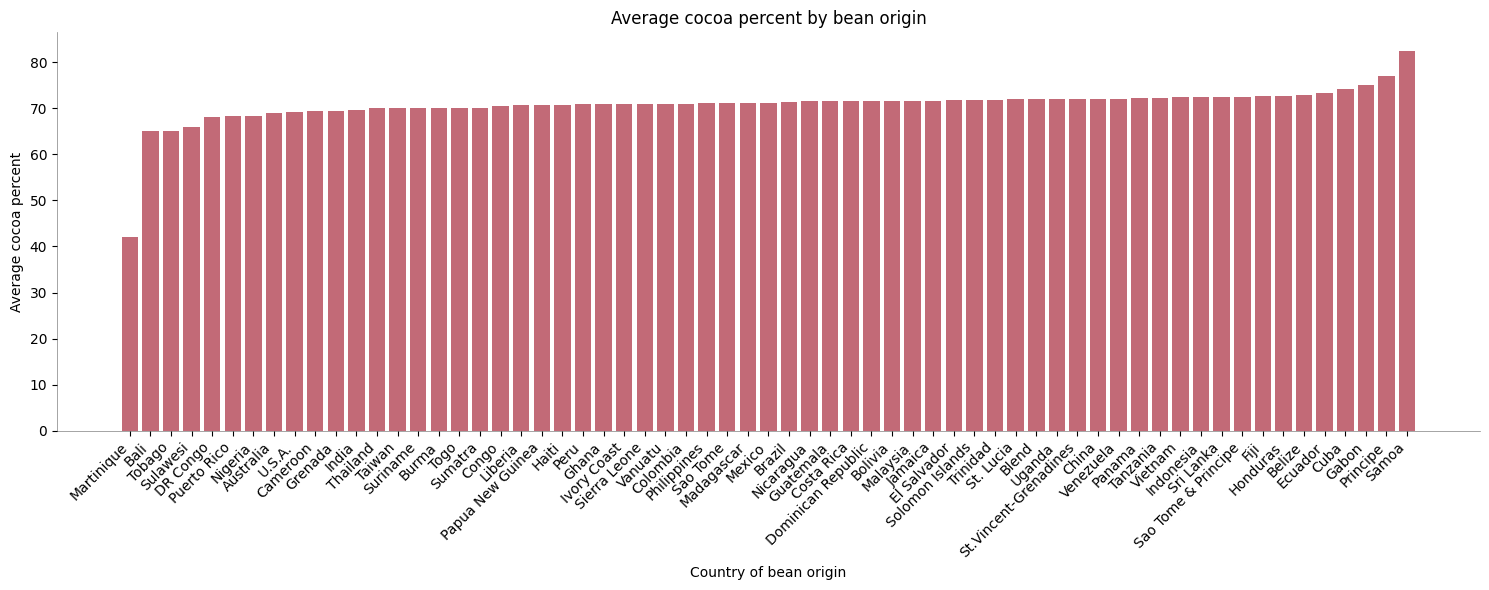

In [13]:
plt.figure(figsize=(15, 6))
plt.bar(avg_cocoa_percent.index, 
        avg_cocoa_percent.values, 
        color='#C26A77')

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_alpha(0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('Country of bean origin')
plt.ylabel('Average cocoa percent')
plt.title('Average cocoa percent by bean origin')
plt.xticks(rotation=45, ha = 'right')
plt.tight_layout()

plt.show()



I tried several groupby() comparisons in the following cells.

In [ ]:
# Group by bean origin and find the average rating of bars produced with beans from that country
avg_country_origin_rating = df.groupby('Bean Origin')['Rating'].mean().sort_values()
avg_country_origin_rating

Bean Origin
Bali                     2.500000
Puerto Rico              2.714286
Principe                 2.750000
Martinique               2.750000
St.Vincent-Grenadines    2.750000
                           ...   
Congo                    3.318182
Solomon Islands          3.450000
China                    3.500000
Sao Tome & Principe      3.500000
Tobago                   3.625000
Name: Rating, Length: 63, dtype: float64

In [ ]:
# Find the avg rating of bars containing certain percentages of cocoa. Example output: "The average rating for bars with 53% cocoa is 2.0"
avg_cocoa_percent_rating = df.groupby('Cocoa %')['Rating'].mean().sort_values()
avg_cocoa_percent_rating

Cocoa %
53.0     2.000000
91.0     2.166667
100.0    2.285714
89.0     2.625000
99.0     2.625000
42.0     2.750000
46.0     2.750000
57.0     2.750000
60.5     2.750000
72.5     2.750000
84.0     2.812500
55.0     2.859375
81.0     2.916667
61.0     2.964286
90.0     2.972222
62.0     2.984375
85.0     3.000000
83.0     3.000000
60.0     3.005435
76.0     3.021429
82.0     3.041667
71.0     3.068182
80.0     3.086111
77.0     3.098837
73.5     3.125000
58.0     3.125000
71.5     3.125000
75.0     3.161859
65.0     3.163978
64.0     3.195946
73.0     3.197761
74.0     3.213768
72.0     3.216828
88.0     3.218750
56.0     3.250000
79.0     3.250000
87.0     3.250000
86.0     3.250000
70.0     3.265421
68.0     3.290000
67.0     3.335714
66.0     3.348214
78.0     3.386364
69.0     3.461538
63.0     3.500000
50.0     3.750000
Name: Rating, dtype: float64

I chose a scatterplot to show a relationship or pattern between the amount of cocoa in a chocolate bar and the rating it gets.
This scatterplot helped me notice that most of chocolate bars with 60-80% cocoa had ratings between 2.5 - 4.0.     

In [94]:
avg_rating_cocoa_percent = df.groupby('Rating')['Cocoa Percent'].mean().sort_values(ascending=False)
avg_rating_cocoa_percent

Rating
1.75    90.666667
1.50    84.800000
1.00    78.250000
2.00    76.575758
2.25    73.294118
2.75    72.056047
3.00    71.705993
2.50    71.653846
3.25    71.405063
3.50    71.211473
3.75    71.014706
4.00    70.756522
Name: Cocoa Percent, dtype: float64

In [115]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2588 entries, 0 to 2587
Data columns (total 10 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   REF                               2588 non-null   int64  
 1   Company (Manufacturer)            2588 non-null   str    
 2   Company Location                  2588 non-null   str    
 3   Review Date                       2588 non-null   int64  
 4   Country of Bean Origin            2588 non-null   str    
 5   Specific Bean Origin or Bar Name  2588 non-null   str    
 6   Cocoa Percent                     2588 non-null   float64
 7   Ingredients                       2501 non-null   str    
 8   Most Memorable Characteristics    2588 non-null   str    
 9   Rating                            2588 non-null   float64
dtypes: float64(2), int64(2), str(6)
memory usage: 202.3 KB


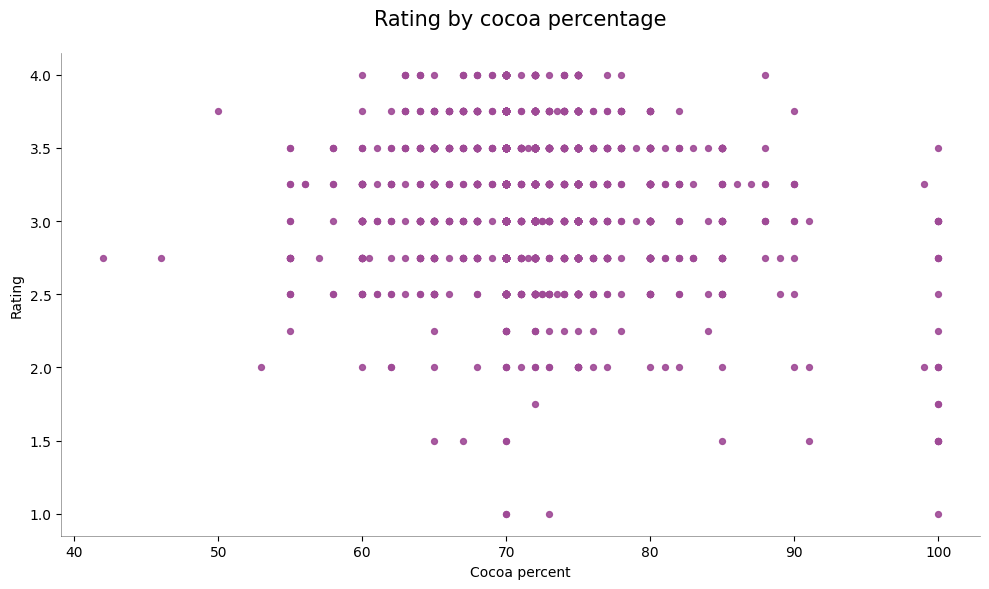

In [10]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Cocoa %'], 
            df['Rating'], 
            color = '#9F4A96', 
            alpha = 0.9,
            s = 18)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_alpha(0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('Cocoa percent')
plt.ylabel('Rating')
plt.title('Rating by cocoa percentage', fontsize=15, pad=20)

plt.tight_layout()

plt.show()

To explore how bean origin affects chocolate bar rating, I used another bar plot, which is appropriate for comparing quantities (in this case, rating, which was treated as a quantity by Python) across categories. In this case, I ordered the ratings in descending order.

In [20]:
highest_rating_bean_origin = df.groupby('Bean Origin')['Rating'].max().sort_values(ascending=False)
highest_rating_bean_origin 

Bean Origin
Belize                   4.00
Bolivia                  4.00
Blend                    4.00
Brazil                   4.00
Dominican Republic       4.00
                         ... 
Sri Lanka                3.00
Principe                 2.75
Martinique               2.75
St.Vincent-Grenadines    2.75
Bali                     2.50
Name: Rating, Length: 63, dtype: float64

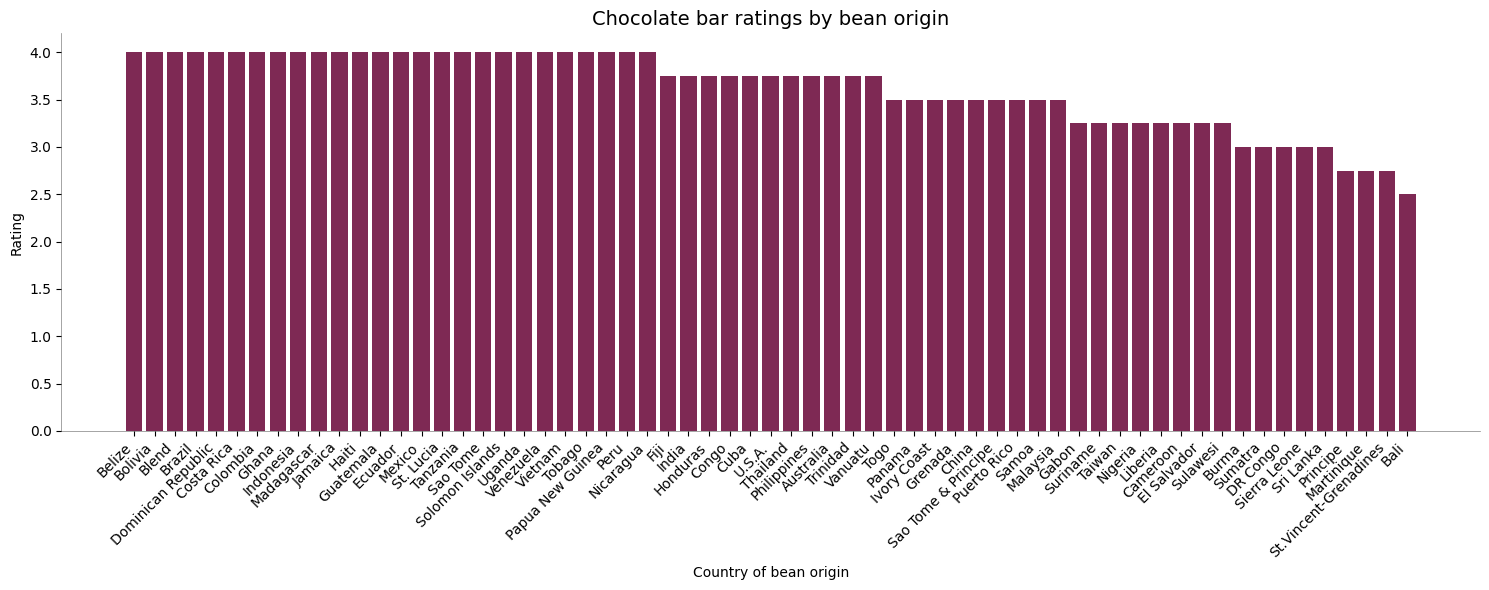

In [21]:
plt.figure(figsize=(15, 6))
plt.bar(
    highest_rating_bean_origin.index,
    highest_rating_bean_origin.values,
    color='#7E2954')

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_alpha(0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('Country of bean origin')
plt.ylabel('Rating')
plt.title('Chocolate bar ratings by bean origin', fontsize=14)
plt.xticks(rotation=45, ha = 'right')
plt.tight_layout()

plt.show()

This data was collected from 2006 - 2022. I added a line graph to see if the ratings changed from year to year. 

I changed the y axis to start with zero to eliminate the appearance of exaggerated data. It appears that average chocolate bar ratings did not vary much from year to year. The yearly averages tended to hover between  3.0 and 3.5, which coincides with the overall mean of 3.19 that was calculated earlier in this analysis. I started to add an xtick for each year (vs every other year) but I like the simplicity of the x-axis without it, and all of the data points are still there. 

In [23]:
annual_avg_rating = df.groupby('Review Date')['Rating'].mean().round(2)
annual_avg_rating

Review Date
2006    3.00
2007    3.10
2008    3.00
2009    3.07
2010    3.15
2011    3.26
2012    3.18
2013    3.20
2014    3.19
2015    3.24
2016    3.23
2017    3.36
2018    3.19
2019    3.13
2020    3.26
2021    3.32
2022    3.28
Name: Rating, dtype: float64

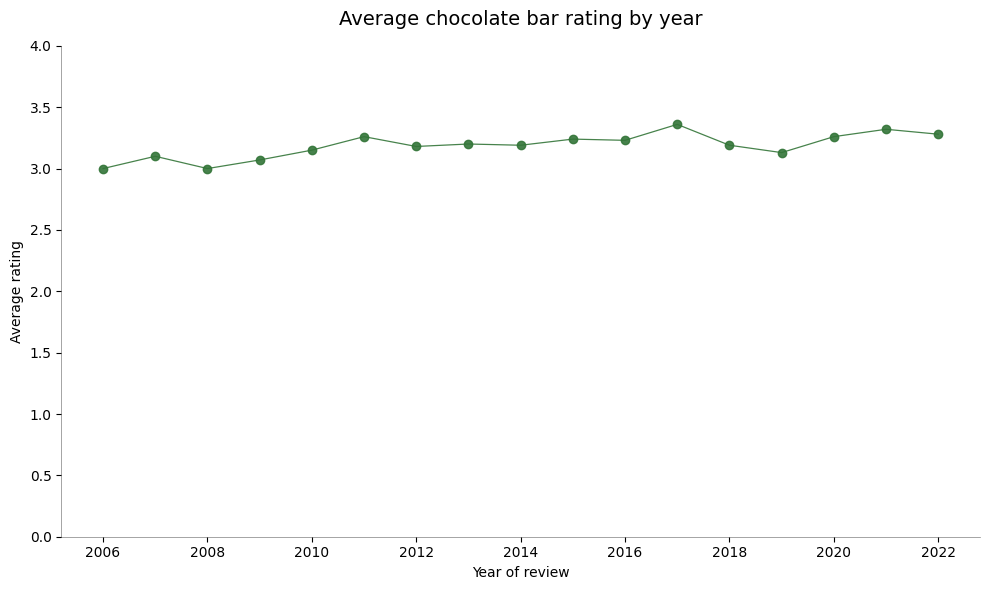

In [24]:
plt.figure(figsize=(10,6))
plt.plot(annual_avg_rating.index, 
         annual_avg_rating.values,
         linewidth=.9,
         marker = 'o',
         color='#337538',
         alpha=.9)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_alpha(0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('Year of review')
plt.ylabel('Average rating')
plt.ylim(0, 4)
plt.title("Average chocolate bar rating by year", fontsize=14, pad=15)
#plt.xticks((np.arange(2006, 2023, 1.0)), rotation=45, ha = 'right')
plt.tight_layout()

plt.show()

Next, I'd like to create a histogram to view the distribution of number of reviews according to year, since there were much fewer reviews during some years than others.

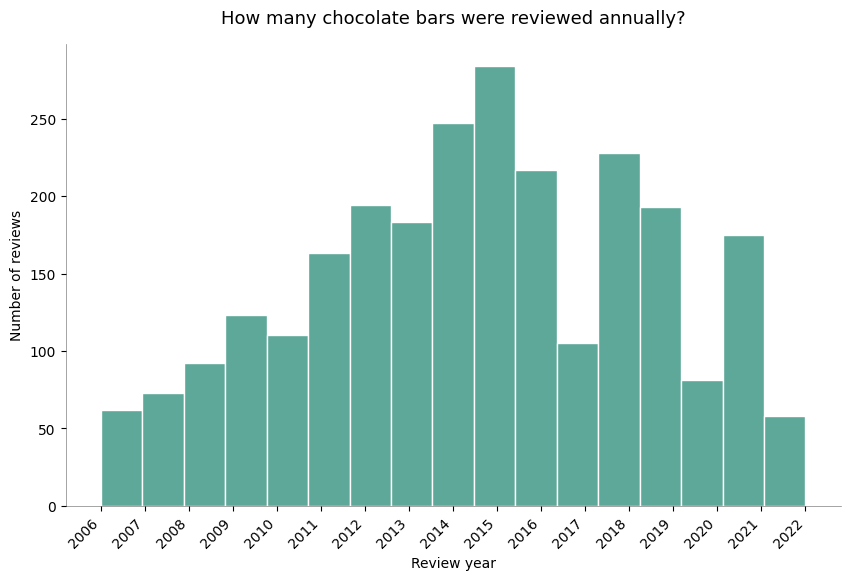

In [25]:
plt.figure(figsize=(10, 6))
plt.hist(
    df['Review Date'],
    bins=17, 
    color='#5DA899',
    edgecolor='white'
)

plt.xlabel('Review year')
plt.ylabel('Number of reviews')
plt.title('How many chocolate bars were reviewed annually?', fontsize=13, pad=15)
plt.xticks((np.arange(2006, 2023, 1.0)), rotation=45, ha='right')#plt.xticks((np.arange(2006, 2023, 1.0)), rotation=45, ha = 'right')


ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_alpha(0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

This chart tells us that there was a surge in reviews in 2014 and 2015, and dips in number of reviews in 2017, 2020, and 2022. We do not have enough information to explain these findings. Did the club responsible for these reviews gain in popularity in 2014-15?  Why did it surge again in 2018 and 2021?  Did the Covid pandemic impact numbers for 2020?  We don't know.

I created an Entity Relationship Diagram, and now it is time to build relational tables with Sqlite3.  

In [26]:
# make the database connection
conn = sqlite3.connect('chocolate_bar_ratings_2022.db')

chocolate_bar_df = df[['REF', 'Bar Name', 'Company', 'Cocoa %', 'Ingredients', 'Rating']].drop_duplicates().rename(columns = {
    'Bar Name': 'bar_name',
    'Company': 'company',
    'Cocoa %': 'cocoa_%',
    'Ingredients': 'ingredients',
    'Rating': 'rating'
})

bean_origin_df = df[['Characteristics', 'Rating', 'REF']].drop_duplicates().rename(columns = {
    'Characteristics': 'characteristics',
    'Rating': 'rating'
})

reviews_df = df[['Review Date', 'Rating', 'Ingredients', 'Characteristics']].drop_duplicates().rename(columns = {
    'Review Date': 'review_date',
    'Rating': 'rating',
    'Ingredients': 'ingredients',
    'Characteristics': 'characteristics'
})

manufacturer_country_df = df[['Rating', 'Ingredients', 'Company Location']].drop_duplicates().rename(columns = {
    'Rating': 'rating',
    'Ingredients': 'ingredients', 
    'Company Location': 'company_location'
})

chocolate_bar_df.to_sql('chocolate_bar', conn, index = False, if_exists = 'replace')
bean_origin_df.to_sql('bean_origin', conn, index = False, if_exists = 'replace')
reviews_df.to_sql('reviews', conn, index = False, if_exists = 'replace')
manufacturer_country_df.to_sql('manufacturer_country', conn, index = False, if_exists = 'replace')
conn.commit()

The database was created successfully.

I also created a separate DataFrame for each database table and save it as its own unique csv file.

In [7]:
chocolate_bar_df.to_csv('../data/chocolate_bar.csv')
bean_origin_df.to_csv('../data/bean_origin.csv')
reviews_df.to_csv('../data/reviews.csv')
manufacturer_country_df.to_csv('../data/manufacturer_country.csv')

Now I will make some queries based on my project questions.    

What are the characteristics and ingredients of the highest-rated chocolate bars? 

In [12]:
query1 = """
SELECT 
    c.rating,
    r.characteristics
FROM chocolate_bar c
JOIN reviews r ON c.rating = r.rating
WHERE c.rating = 4.0
"""    

In [13]:
result1 = pd.read_sql_query(query1, conn)
result1

,rating,characteristics
0,4.0,"balanced, cherry, choco"
1,4.0,"balanced, nuts, strawberry"
2,4.0,"banana, pear, spice, cheese"
3,4.0,"banana, yogurt, cocoa"
4,4.0,"banana,dairy, cocoa"
...,...,...
13220,4.0,"tangy, floral, spicy, cocoa"
13221,4.0,"tart, lemon, smoke"
13222,4.0,"tart, red berry, smoke"
13223,4.0,"tart, roasted cocoa"


Find the number of rows with 4.0 rating.

In [43]:
query2 = """
SELECT COUNT (c.rating)
FROM chocolate_bar c
WHERE c.rating = 4.0
"""

In [44]:
result2 = pd.read_sql_query(query2, conn)
result2

,COUNT (c.rating)
0,115


This matches the 4.0 rating value counts (115) in the original exploratory data analysis notebook.  

I want to find the most frequently occurring words in the characteristics column for bars rated 4.0. First, I need to select just the characteristics column, so it creates its own series.  

In [55]:
query3 = """
SELECT 
    r.characteristics
FROM reviews r
WHERE r.rating = 4.0
"""   

In [62]:
result3 = pd.read_sql_query(query3, conn)
result3

,characteristics
0,"oily, nut, caramel, raspberry"
1,"sweet, cocoa, tangerine"
2,"delicate, hazelnut, brownie"
3,"light color, fruit, yogurt"
4,"strong spice, intense pepper"
...,...
110,"green,unripened fruit,banana"
111,"intense, dark berry, grapes"
112,"complex, hazelnut, dairy, fruit"
113,"rich cocoa, spicy, cinamon"


I made a word cloud with this. The larger the word, the more frequently it occurs.

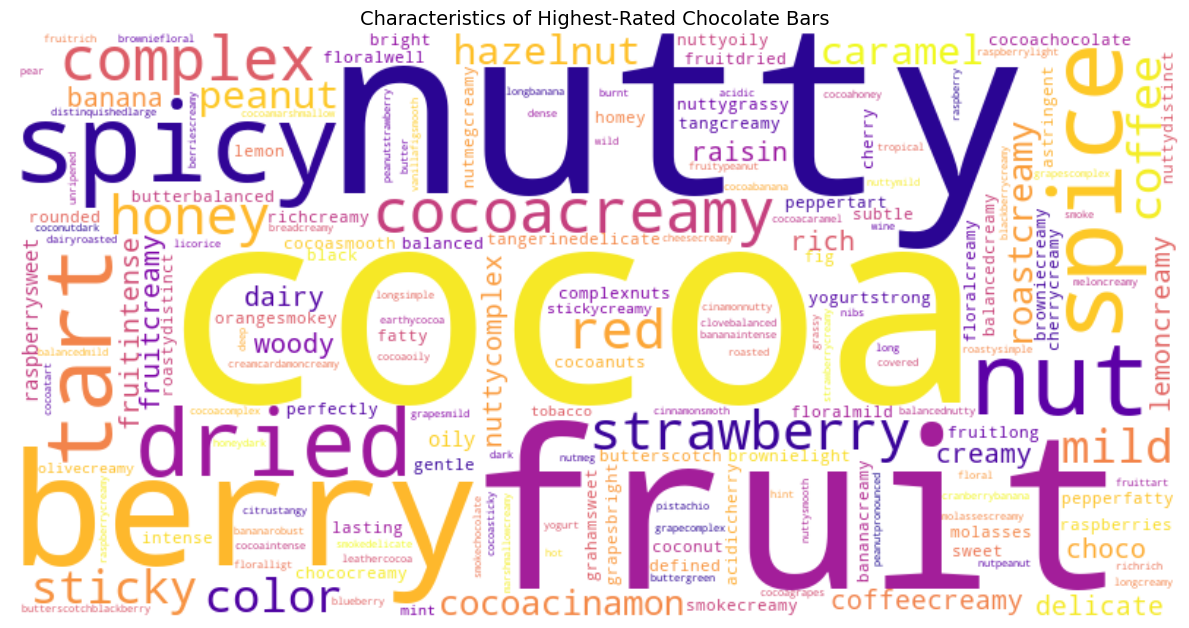

In [76]:
text = ''.join(result3['characteristics'])

wc = WordCloud(width=800, height=400, background_color='white', colormap='plasma').generate(text)
plt.figure(figsize=(12, 8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Characteristics of Highest-Rated Chocolate Bars', fontsize=14)
plt.tight_layout()
plt.show()

What are the most common characteristics in the lowest-rated bars (1.0 rating)?

In [86]:
query4 = """
SELECT 
    r.characteristics
FROM reviews r
WHERE r.rating BETWEEN 0 AND 1.99
"""    

In [87]:
result4 = pd.read_sql_query(query4, conn)
result4

,characteristics
0,"cocoa, dominate off note"
1,"very nutty, very bitter"
2,"acidic, bitter, dry"
3,"cardboard, very bitter, floral"
4,"klingy, hint of fruit, very bitter"
5,"bitter, cocoa"
6,"chalky, musty, very bitter"
7,high intensity bitter
8,this is not chocolate
9,"acidic, astringent, unpleasant"


Another wordcloud, this time for the characteristics of the lowest-rated bars:

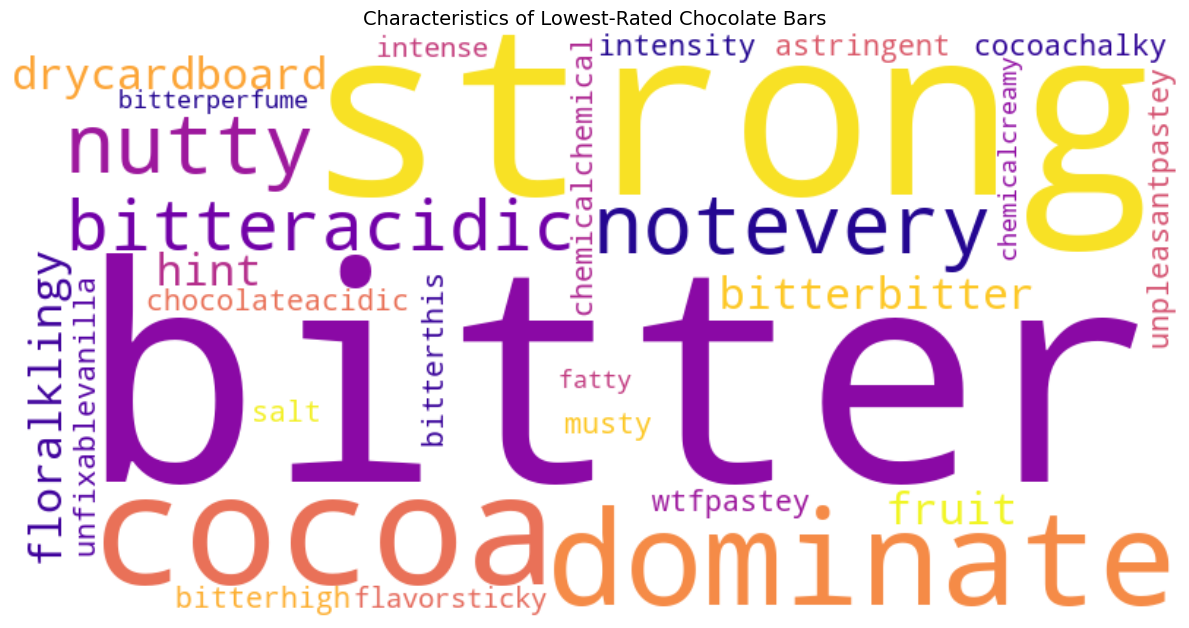

In [ ]:
text = ''.join(result4['characteristics'])

wc = WordCloud(width=800, height=400, background_color='white', colormap='plasma').generate(text)   
plt.figure(figsize=(12, 8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Characteristics of Lowest-Rated Chocolate Bars', fontsize=14)
plt.tight_layout()
plt.show()

As expected, the words in the highest ratings were positive and most descriptions of low-rated bars were negative. A prominent word in both clouds was "cocoa", which is not surprising, since reviewers were tasting chocolate.

Now I would like to see the most common ingredients in the highest rated chocolate bars.

In [21]:
#Locating the ingredients in the highest-rated bars
query5 = """ 
SELECT 
    c.rating,
    c.ingredients
FROM chocolate_bar c
WHERE c.rating = 4.0
"""

In [22]:
result5 = pd.read_sql_query(query5, conn)
result5

,rating,ingredients
0,4.0,"4- B,S,C,L"
1,4.0,"3- B,S,C"
2,4.0,"4- B,S,C,L"
3,4.0,"4- B,S,C,L"
4,4.0,"4- B,S,C,V"
...,...,...
110,4.0,"5- B,S,C,V,L"
111,4.0,"5- B,S,C,V,L"
112,4.0,"3- B,S,C"
113,4.0,"3- B,S,C"


How many distinct values did the above query (query5) return?

In [23]:
query6 = """
SELECT DISTINCT 
    c.ingredients
FROM chocolate_bar c
WHERE c.rating = 4.0
"""

In [24]:
result6 = pd.read_sql_query(query6, conn)
result6

,ingredients
0,"4- B,S,C,L"
1,"3- B,S,C"
2,"4- B,S,C,V"
3,"2- B,S"
4,"5- B,S,C,V,L"


It appears that highly-rated chocolate bars contain five unique combinations of ingredients:     
1. Beans, sugar, cocoa butter, lecithin    
2. Beans, sugar, cocoa butter    
3. Beans, sugar, cocoa butter, vanilla
4. Beans, sugar
5. Beans, sugar, cocoa butter, vanilla, lecithin

What are the ingredients of the lowest-rated bars?

In [25]:
query7 = """
SELECT 
    c.rating,
    c.ingredients
FROM chocolate_bar c
WHERE c.rating BETWEEN 0 AND 1.99
"""

In [26]:
result7 = pd.read_sql_query(query7, conn)
result7

,rating,ingredients
0,1.75,"3- B,S,C"
1,1.75,"3- B,S,C"
2,1.50,"3- B,S,C"
3,1.50,"3- B,S,C"
4,1.50,"4- B,S,C,L"
5,1.00,"3- B,S,C"
6,1.00,"3- B,S,C"
7,1.50,"3- B,S,C"
8,1.00,"3- B,S,C"
9,1.50,"3- B,S,L"


Find how many distinct values:

In [27]:
query8 = """
SELECT DISTINCT 
    c.ingredients
FROM chocolate_bar c
WHERE c.rating BETWEEN 0 AND 1.99
"""

In [28]:
result8 = pd.read_sql_query(query8, conn)
result8

,ingredients
0,"3- B,S,C"
1,"4- B,S,C,L"
2,"3- B,S,L"
3,"4- B,S*,C,Sa"
4,"5- B,S,C,V,L"


Low-rated chocolate bars also contain five unique combinations of ingredients:     
1. Beans, sugar, cocoa butter    
2. Beans, sugar, cocoa butter, lecithin    
3. Beans, sugar, lecithin
4. Beans, alternative sweetener, cocoa butter, salt
5. Beans, sugar, cocoa butter, vanilla, lecithin

In [17]:
conn.close()